In [1]:
import numpy as np
import PcmPy as pcm
import pandas as pd
import os
import SensoriMotorPrediction.globals as gl
import matplotlib.pyplot as plt
import scipy

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


In [2]:
def ancova_regress_out_cv(B, F, Z, part_vec):
    n_f   = F.shape[1]
    B_res  = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p   # all partitions except p
        test  = part_vec == p   # partition p

        # Remove condition-mean structure from F in both sets
        F_train = F[train]
        F_test  = F[test]

        # Estimate W_F with OLS
        X_train = np.c_[F_train, Z[train]]
        W_train_ols = np.linalg.pinv(X_train) @ B[train]

        # Apply only F's contribution to the test partition
        B_res[test] = B[test] - F_test @ W_train_ols[:n_f]

    return B_res

def ols_regress_out_cv(B, F, part_vec):
    B_res = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p
        test  = part_vec == p

        # Estimate W_F on training partitions using F only
        W_train_ols = np.linalg.pinv(F[train]) @ B[train]

        # Apply to test partition
        B_res[test] = B[test] - F[test] @ W_train_ols

    return B_res

def run_simulation(n_cond=5, n_part=10, n_vox=500, n_channel=1, r_FZ=0.5, iterations=100):
    n_obs   = n_cond * n_part
    D_res = {k: np.zeros((iterations, n_cond, n_cond)) for k in ['raw', 'ols', 'ols_cv', 'ancova', 'ancova_cv']}

    for i in range(iterations):
        rng      = np.random.default_rng(i)
        cond_vec = np.tile(np.arange(n_cond), n_part)
        part_vec = np.repeat(np.arange(n_part), n_cond)
        Z        = pcm.indicator(cond_vec)
        X_part   = pcm.indicator(part_vec)

        B  = rng.standard_normal((n_obs, n_vox))

        F  = (np.sqrt(r_FZ) * (Z @ rng.standard_normal((n_cond, n_channel)))
            + np.sqrt(1 - r_FZ) * rng.standard_normal((n_obs, n_channel)))
        F -= F.mean(axis=0, keepdims=True)

        W = np.linalg.pinv(np.c_[F, Z]) @ B

        X = np.c_[F, np.ones(F.shape[0])]

        B_res = {
            'raw':       B,
            'ols':       B - X @ np.linalg.pinv(X) @ B,
            'ols_cv':    ols_regress_out_cv(B, X, part_vec),
            'ancova':    B - F @ W[:n_channel],
            'ancova_cv': ancova_regress_out_cv(B, F, Z, part_vec),
        }

        for k, b in B_res.items():
            G, _ = pcm.est_G_crossval(b, cond_vec, part_vec, X=X_part)
            D_res[k][i] = pcm.G_to_dist(G) #.mean()

    return B_res, D_res

In [3]:
data = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
data.cue = data.cue.map(gl.regressor_mapping)
r2 = 0
for sn, df in data.groupby('sn'):
    F = df.diff0.values[:, None]
    F = F - F.mean()

    Z = pcm.indicator(df.cue)
    F_hat = Z @ np.linalg.pinv(Z) @ F
    r2 += (F_hat ** 2).sum() / (F ** 2).sum()

r2 /= data.sn.nunique()

print(f'Average R2 between Z and F: {r2}')

Average R2 between Z and F: 0.1800923312315199


In [4]:
n_iter = 100
B_res, D_res = run_simulation(r_FZ=r2, iterations=n_iter)
D_raw = D_res['raw'].reshape(-1, 25)
D_ols = D_res['ols'].reshape(-1, 25)
D_ols_cv = D_res['ols_cv'].reshape(-1, 25)
D_ancova = D_res['ancova'].reshape(-1, 25)
D_ancova_cv = D_res['ancova_cv'].reshape(-1, 25)

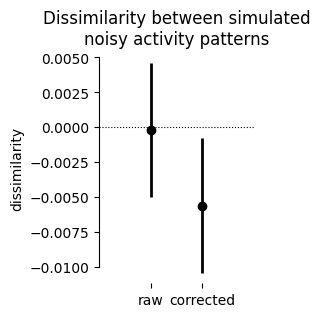

In [6]:
fig, ax = plt.subplots(figsize=(2, 3))
method = ['raw', 'corrected', ] #'ols_cv', 'ancova', 'ancova_cv']
D_mean = np.r_[D_raw.mean(), D_ols.mean(),] # D_ols_cv.mean(), D_ancova.mean(), D_ancova_cv.mean()]
D_std = np.r_[D_raw.mean(axis=-1).std(), ] #D_ols.mean(axis=-1).std(), D_ols_cv.mean(axis=-1).std(), D_ancova.mean(axis=-1).std(), D_ancova_cv.mean(axis=-1).std()]
ax.errorbar(method, D_mean, yerr=D_std,color='k', lw=2, ls='none', marker='o')
ax.axhline(0, color='k', lw=.8, ls=':')
ax.set_xlim((-1, 2))
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.spines['left'].set_bounds(-.01, .005)
ax.set_ylabel('dissimilarity')
ax.set_title('Dissimilarity between simulated\nnoisy activity patterns')
fig.savefig(os.path.join('figures', 'simulation.dissimilarity.pdf'))

plt.show()

r=0.7653718614458673, 95% CI=[0.7035204094844197, 0.8157157613872946]


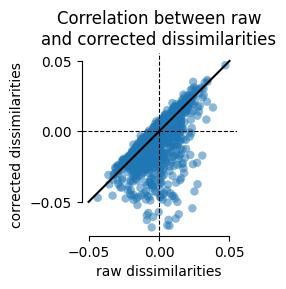

In [9]:
corr = np.diag(np.corrcoef(np.r_[D_raw, D_ols])[:n_iter, n_iter:])

# calc 95% CI
alpha=.05
z = np.arctanh(corr)
z_mean = np.mean(z)
z_se = np.std(z, ddof=1) / np.sqrt(len(z))
z_crit = scipy.stats.norm.ppf(1 - alpha / 2)
z_low = z_mean - z_crit * z_se
z_high = z_mean + z_crit * z_se
mean_r = np.tanh(z_mean)
ci_low = np.tanh(z_low)
ci_high = np.tanh(z_high)

print(f'r={mean_r}, 95% CI=[{ci_low}, {ci_high}]')

fig, ax = plt.subplots(figsize=(2, 3))
ax.scatter(D_raw.flatten(), D_ols.flatten(), alpha=.3, edgecolor='none', label='OLS', marker='o')
# ax.scatter(D_raw.flatten(), D_ols_cv.flatten(), alpha=.3, edgecolor='none', label='OLS-CV', marker='s')
# ax.scatter(D_raw.flatten(), D_ancova.flatten(), alpha=.3, label='ANCOVA', marker='x')
# ax.scatter(D_raw.flatten(), D_ancova_cv.flatten(), alpha=.3, label='ANCOVA-CV', marker='+')
ax.plot([-.05, .05], [-.05, .05], color='k', )
ax.axhline(0, color='k', lw=.8, ls='--')
ax.axvline(0, color='k', lw=.8, ls='--')
ax.set_aspect('equal')
ax.set_yticks([-.05, 0, .05])
ax.set_xticks([-.05, 0, .05])
ax.spines[['left', 'bottom']].set_bounds(-.05, .05)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('corrected dissimilarities')
ax.set_xlabel('raw dissimilarities')

ax.set_title('Correlation between raw\nand corrected dissimilarities')

fig.savefig(os.path.join('figures', 'simulation.correlation.pdf'))

#ax.legend(bbox_to_anchor=(1, .5), loc='center left')

plt.show()

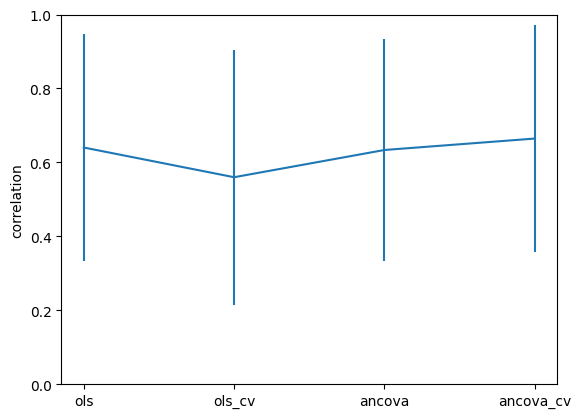

In [ ]:
corr_mat = np.corrcoef(np.r_[D_raw, D_ols, D_ols_cv, D_ancova, D_ancova_cv])

corr = np.array([
    np.diag(corr_mat[0:n_iter, j * n_iter:(j + 1) * n_iter])
    for j in range(1, 5)
])

corr_avg = corr.mean(axis=1)
corr_std = corr.std(axis=1)

fig, ax = plt.subplots()

ax.errorbar(method[1:], corr_avg, yerr=corr_std)
ax.set_ylim(0, 1)
ax.set_ylabel('correlation')

plt.show()